<a href="https://colab.research.google.com/github/BrandosQuest/CyberMediaProject/blob/master/SpectrogramComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install musdb mir_eval soundfile


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Brando\AppData\Local\Python\pythoncore-3.11-64\python.exe -m pip install --upgrade pip


In [7]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import glob
import IPython.display as ipd
import musdb
import IPython.display as ipd
import mir_eval
import soundfile as sf

In [8]:
mus = musdb.DB(download=True)
track = mus[23]
sr = track.rate
audio=track.audio
audio=np.mean(audio, axis=1)

In [9]:
demucs_outputs = glob.glob("output/*.wav")
HPS_outputs = glob.glob("output/hps/*.wav")

demucs_stems = {}
hps_stems = {}

for file_path in demucs_outputs:
    stem_name = file_path.split('_')[-1].replace('.wav', '')
    demucs_stems[stem_name] = librosa.load(file_path, sr=sr)

for file_path in HPS_outputs:
    stem_name = file_path.split('\\')[-1].replace('.wav', '')
    hps_stems[stem_name] = librosa.load(file_path, sr=sr)

#demucs_stems

In [15]:
stft = librosa.stft(audio)

stft_stems_demucs = {name: librosa.stft(stem_audio[0]) for name, stem_audio in demucs_stems.items()}
stft_stems_hps = {name: librosa.stft(stem_audio[0]) for name, stem_audio in hps_stems.items()}

stftList = [stft] + list(stft_stems_demucs.values()) + list(stft_stems_hps.values())

#stft_stems

In [17]:
dbList = []
for stft_data in stftList:
    dbList.append(librosa.amplitude_to_db(np.abs(stft_data), ref=np.max))

namesList = ["Original Audio"] + list(stft_stems_demucs.keys()) + list(stft_stems_hps.keys())

#namesList

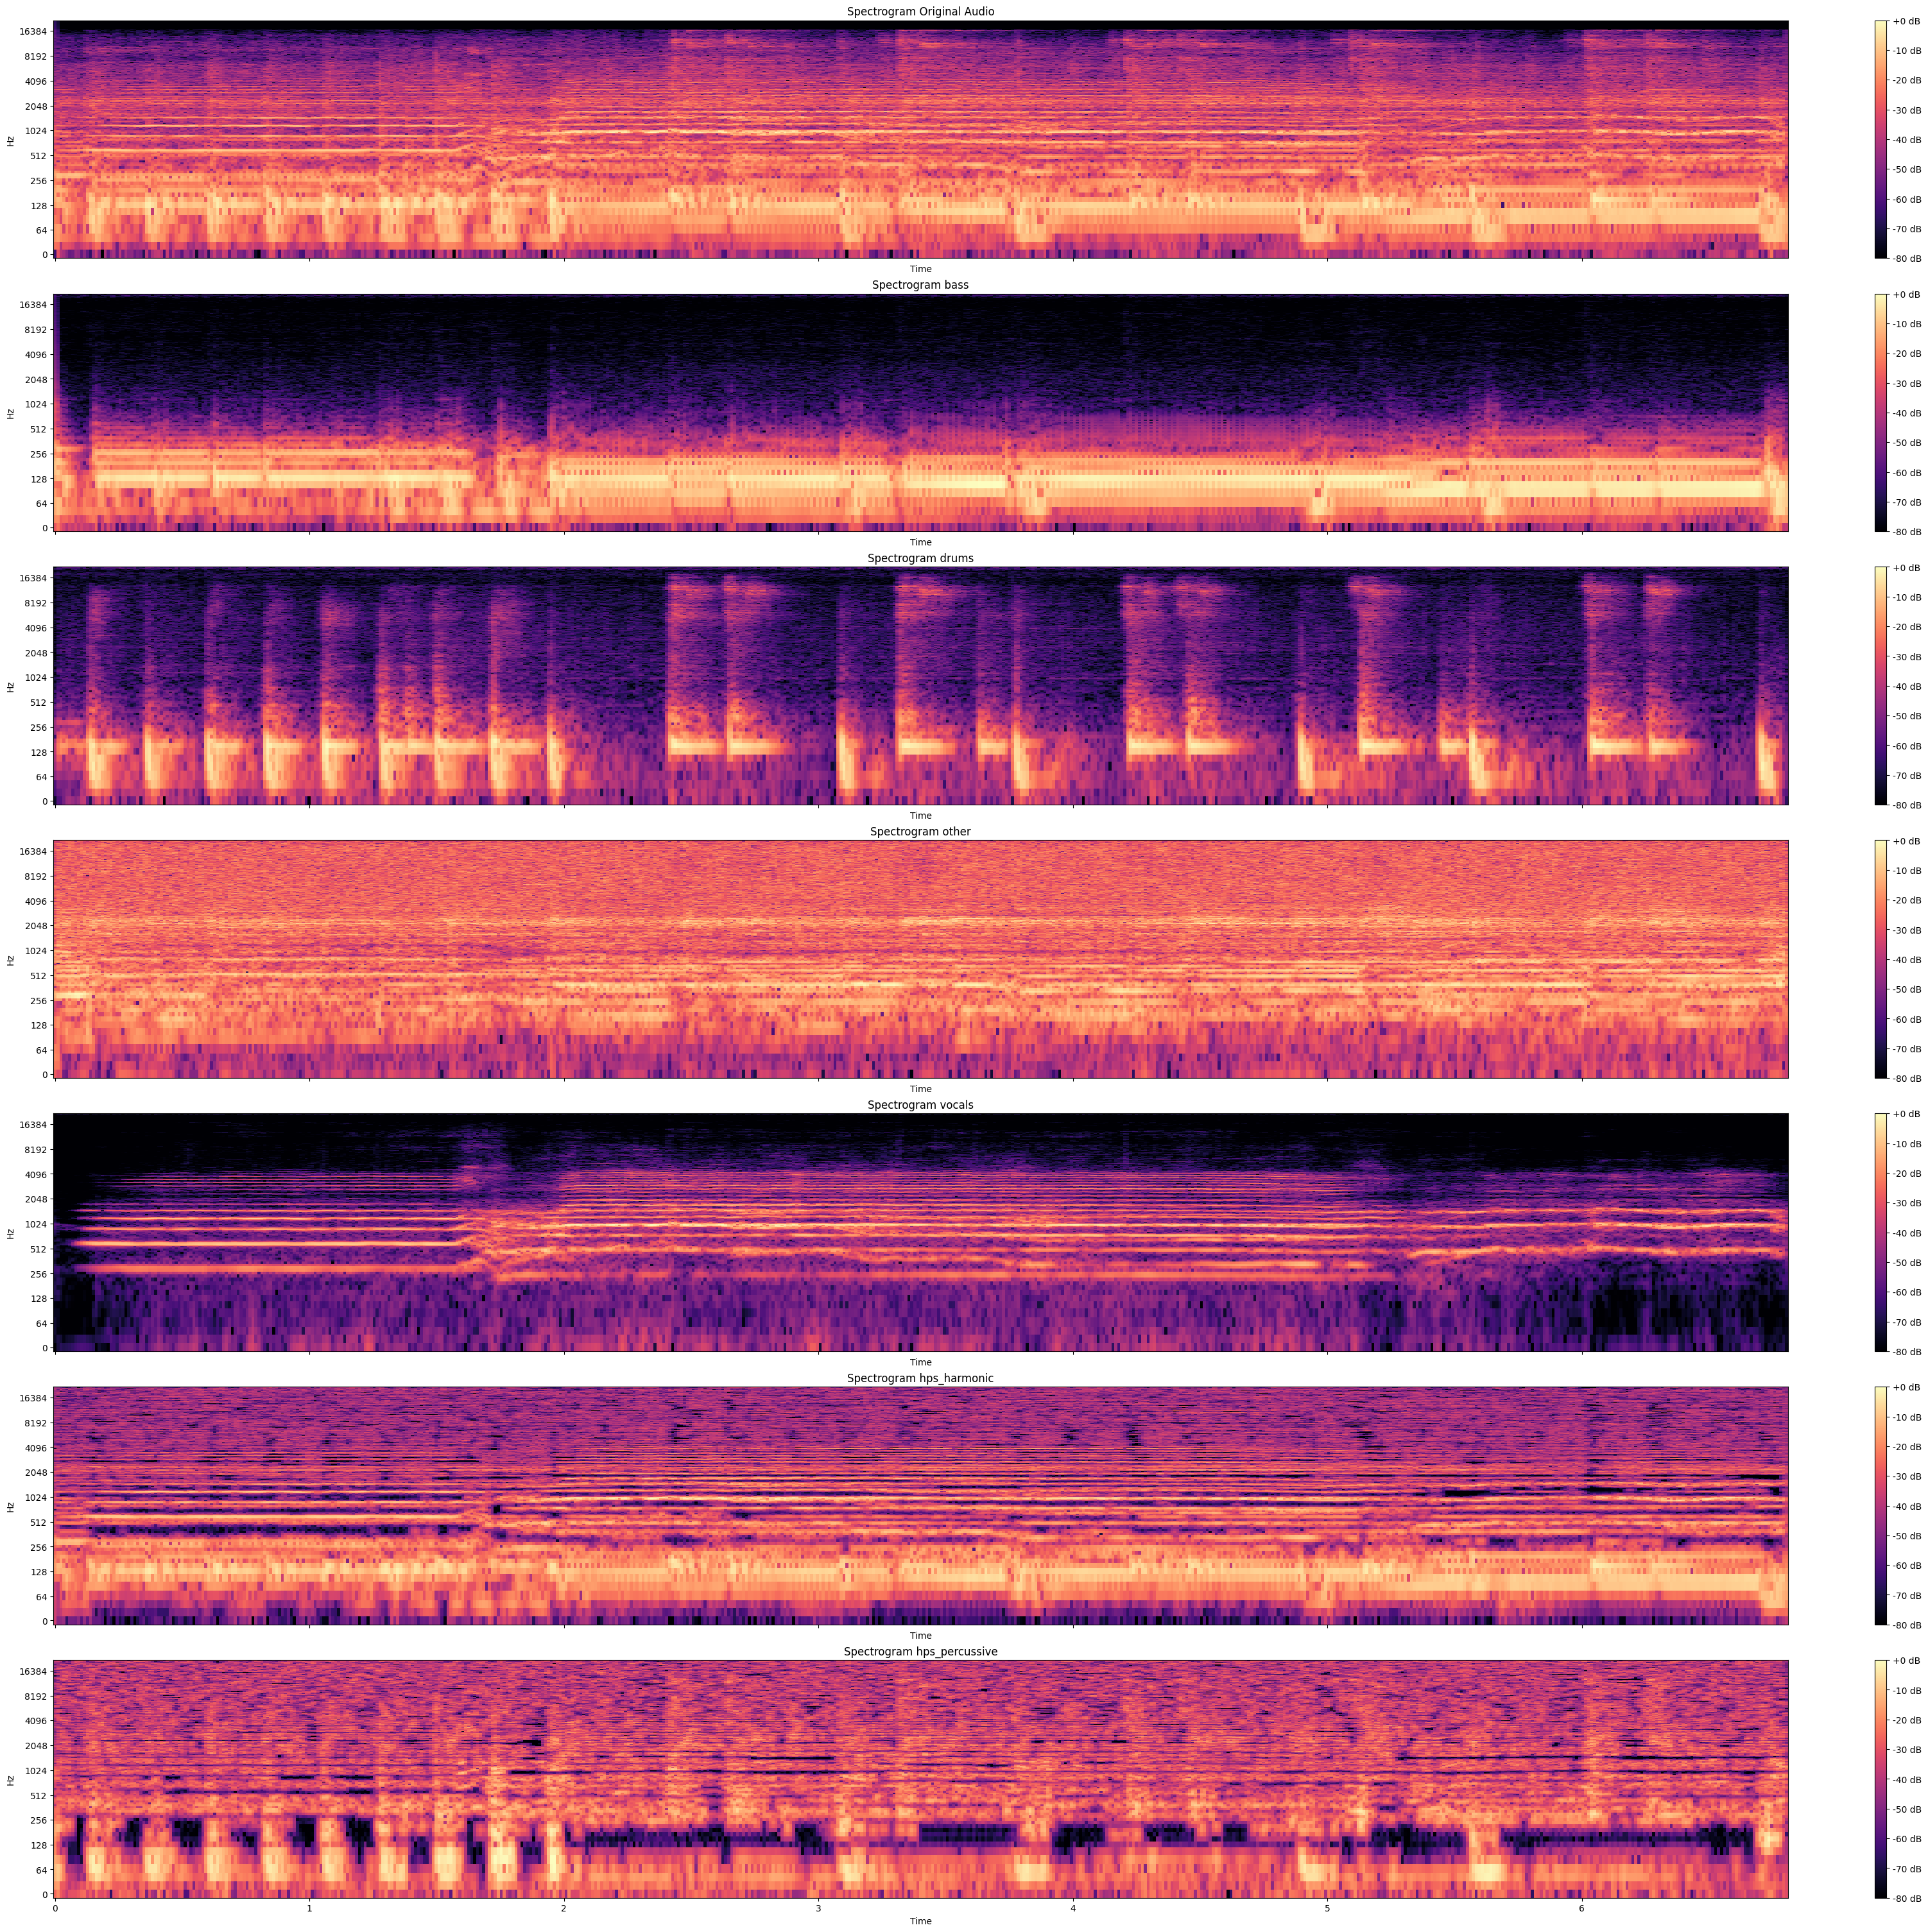

In [18]:
fig, ax = plt.subplots(nrows=len(namesList), ncols=1, figsize=(30, 30), sharex=True, sharey=True, layout='constrained')
specshow_kwargs = dict(sr=sr, x_axis='time', y_axis='log', cmap='magma')

for i, dbStft in enumerate(dbList):
    img = librosa.display.specshow(dbStft, ax=ax[i], **specshow_kwargs)
    fig.colorbar(img, ax=ax[i], format='%+2.0f dB')
    ax[i].set_title(f'Spectrogram {namesList[i]}')

fig.savefig('spectrograms/spectrograms_compared.png', dpi=150, bbox_inches='tight')


#plt.figure(figsize=(10, 6))
#librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz')
#plt.colorbar(format='%+2.0f dB')#capire per quale motivo dobbiamo utilizare i decibel
#plt.title('Spectrogram')
#plt.show()

In [ ]:
mus = musdb.DB(download=True)
track = mus[23]

#print(f"Original Audio: {track.name}")
#display(ipd.Audio(track.audio.T, rate=track.rate))

#print("Isolated Vocals:")
#display(ipd.Audio(track.targets['vocals'].audio.T, rate=track.rate))
#print("Isolated Drums:")
#display(ipd.Audio(track.targets['drums'].audio.T, rate=track.rate))
#print("Isolated other:")
#display(ipd.Audio(track.targets['other'].audio.T, rate=track.rate))
#print("Isolated bass:")
#display(ipd.Audio(track.targets['bass'].audio.T, rate=track.rate))


true_vocals = np.mean(track.targets['vocals'].audio, axis=1)
true_drums = np.mean(track.targets['drums'].audio, axis=1)
true_other = np.mean(track.targets['other'].audio, axis=1)
true_bass = np.mean(track.targets['bass'].audio, axis=1)


est_vocals, _ = demucs_stems["vocals"]
est_drums, _ = demucs_stems["drums"]
est_other, _ = demucs_stems["other"]
est_bass, _ = demucs_stems["bass"]

target_len = len(true_vocals)
est_vocals = librosa.util.fix_length(est_vocals, size=target_len)
est_drums = librosa.util.fix_length(est_drums, size=target_len)
est_other = librosa.util.fix_length(est_other, size=target_len)
est_bass = librosa.util.fix_length(est_bass, size=target_len)

reference_sources = np.vstack([true_vocals, true_drums, true_other, true_bass])
estimated_sources = np.vstack([est_vocals, est_drums, est_other, est_bass])

sdr, sir, sar, perm = mir_eval.separation.bss_eval_sources(
    reference_sources,
    estimated_sources,
    compute_permutation=False
)

print(f"Risultati Voce     -> SDR: {sdr[0]:.2f} dB, SIR: {sir[0]:.2f} dB, SAR: {sar[0]:.2f} dB")
print(f"Risultati Batteria -> SDR: {sdr[1]:.2f} dB, SIR: {sir[1]:.2f} dB, SAR: {sar[1]:.2f} dB")
print(f"Risultati Altro -> SDR: {sdr[2]:.2f} dB, SIR: {sir[2]:.2f} dB, SAR: {sar[2]:.2f} dB")
print(f"Risultati Basso -> SDR: {sdr[3]:.2f} dB, SIR: {sir[3]:.2f} dB, SAR: {sar[3]:.2f} dB")
"""The Metrics Explained
SDR (Signal-to-Distortion Ratio): This is the "Gold Standard" metric. It measures the overall quality of the separated track. Higher is always better.

SIR (Signal-to-Interference Ratio): This measures bleed or leakage. A high SIR means the algorithm successfully blocked out the other instruments.

SAR (Signal-to-Artifacts Ratio): This measures digital artifacts. A low SAR means the track probably sounds "watery," "robotic," or hollow (like a low-quality MP3), even if the other instruments are gone."""

C:\Users\Brando\AppData\Local\Temp\ipykernel_32384\2891702424.py:37: FutureWarning: mir_eval.separation.bss_eval_sources
	Deprecated as of mir_eval version 0.8.
	It will be removed in mir_eval version 0.9.
  sdr, sir, sar, perm = mir_eval.separation.bss_eval_sources(


In [ ]:
import matplotlib.pyplot as plt
import gc

plt.close('all') # Closes all hidden figure windows
gc.collect()     # Forces Python to run garbage collection and free RAM